<a href="https://colab.research.google.com/github/devinaalifia0-alt/Visi-Komputer/blob/main/segmentasi_Warna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import active_contour
from skimage.filters import gaussian

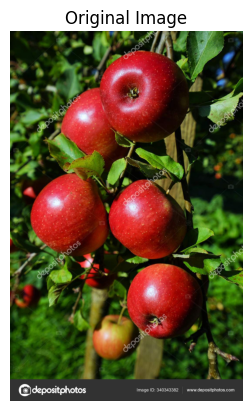

In [3]:
import cv2
import matplotlib.pyplot as plt

# Ganti sesuai nama file di Colab
img = cv2.imread('apel.jpg')

# Cek apakah gambar berhasil dibaca
if img is None:
    print("Gambar tidak ditemukan! Cek nama file.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

(np.float64(-0.5), np.float64(1067.5), np.float64(1699.5), np.float64(-0.5))

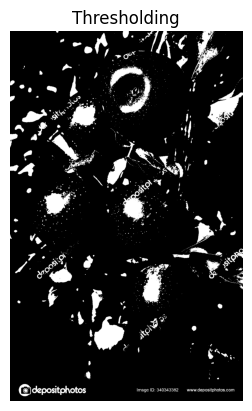

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholding")
plt.axis('off')

In [5]:
gray_float = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) / 255.0
gray_blur = gaussian(gray_float, sigma=2)

In [6]:
s = np.linspace(0, 2*np.pi, 400)
x = 100 + 80*np.cos(s)
y = 100 + 80*np.sin(s)
init = np.array([x, y]).T

In [7]:
snake = active_contour(gray_blur, init, alpha=0.015, beta=10, gamma=0.001)

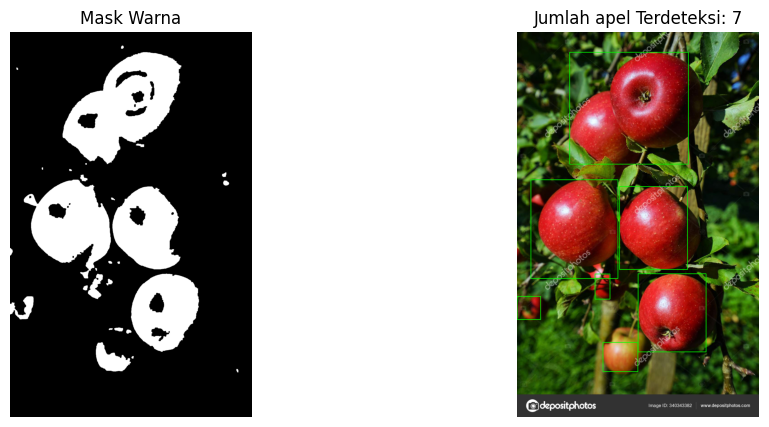

Jumlah apel terdeteksi: 7


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread('apel.jpg')

if img is None:
    raise Exception("Gambar tidak ditemukan!")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# =========================
# 🎯 DETEKSI WARNA (ORANGE/MERAH TRUK)
# =========================
lower1 = np.array([0, 120, 70])
upper1 = np.array([15, 255, 255])

lower2 = np.array([160, 120, 70])
upper2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower1, upper1)
mask2 = cv2.inRange(hsv, lower2, upper2)

mask = mask1 + mask2

# Bersihkan noise
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# =========================
# 🔍 CARI CONTOUR
# =========================
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    # Filter ukuran (biar bukan noise kecil)
    if area > 1000:
        x, y, w, h = cv2.boundingRect(cnt)

        # Filter bentuk (opsional, biar mirip kendaraan)
        if w > 30 and h > 30:
            count += 1
            cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (0,255,0), 2)

# =========================
# 📊 VISUALISASI
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mask, cmap='gray')
plt.title("Mask Warna")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_rgb)
plt.title(f"Jumlah apel Terdeteksi: {count}")
plt.axis('off')

plt.show()

print("Jumlah apel terdeteksi:", count)

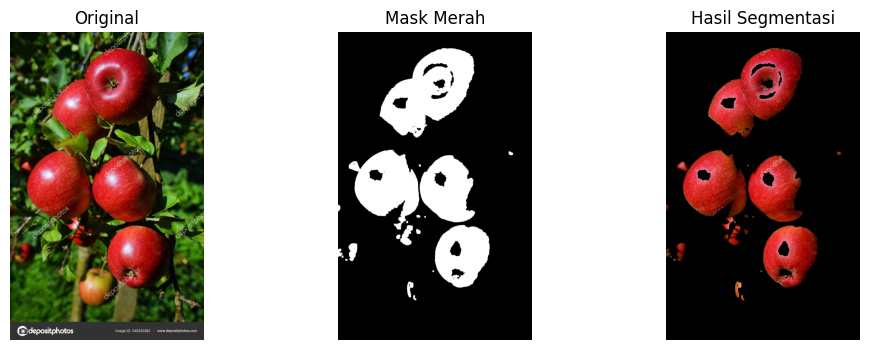

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar (PASTIKAN NAMA FILE BENAR)
img = cv2.imread('apel.jpg')

# Validasi gambar
if img is None:
    raise Exception("Gambar tidak ditemukan / gagal dibaca!")

# Convert ke RGB & HSV
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# =========================
# 🔴 RANGE MERAH (2 BAGIAN)
# =========================
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

# Mask 1 & 2
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

# Gabungkan mask
mask = mask1 + mask2

# Optional: bersihkan noise
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel)

# Terapkan mask ke gambar
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

# =========================
# 📊 VISUALISASI
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask Merah")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(result)
plt.title("Hasil Segmentasi")
plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(1067.5), np.float64(1699.5), np.float64(-0.5))

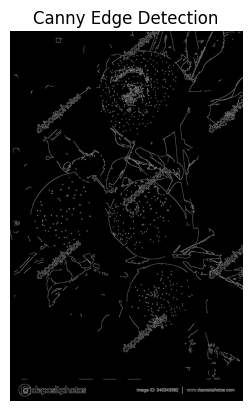

In [10]:
edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

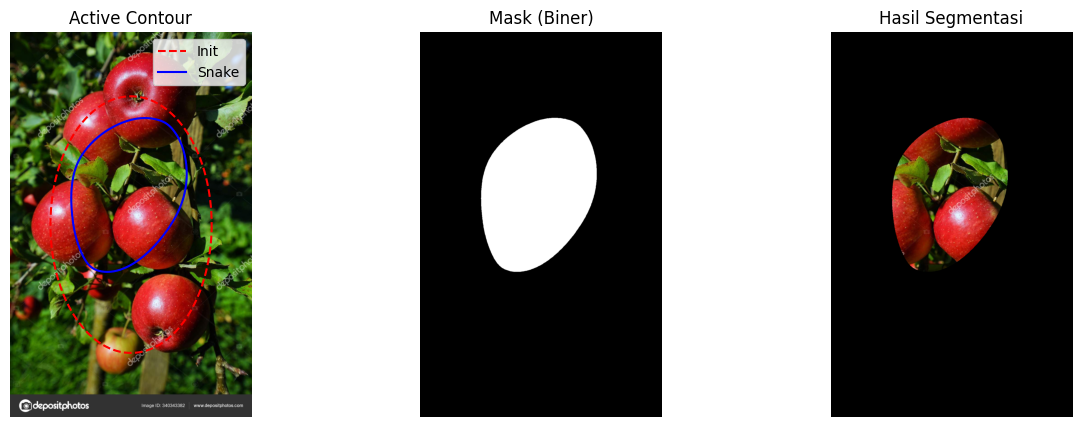

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import active_contour
from skimage.filters import gaussian

# =========================
# 1. LOAD GAMBAR
# =========================
img = cv2.imread('apel.jpg')

if img is None:
    raise Exception("Gambar tidak ditemukan!")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# 2. PREPROCESSING
# =========================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = gray / 255.0

# smoothing biar snake stabil
gray_blur = gaussian(gray, sigma=2)

# =========================
# 3. INISIALISASI KURVA (LINGKARAN)
# =========================
h, w = gray.shape

s = np.linspace(0, 2*np.pi, 400)
x = w/2 + (w/3)*np.cos(s)
y = h/2 + (h/3)*np.sin(s)

init = np.array([x, y]).T

# =========================
# 4. ACTIVE CONTOUR
# =========================
snake = active_contour(
    gray_blur,
    init,
    alpha=0.01,   # elastisitas
    beta=10,      # kekakuan
    gamma=0.001
)

# =========================
# 5. MASKING DARI HASIL SNAKE
# =========================
mask = np.zeros_like(gray, dtype=np.uint8)

snake_int = np.array(snake, dtype=np.int32)
cv2.fillPoly(mask, [snake_int], 255)

# =========================
# 6. APPLY KE RGB
# =========================
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

# =========================
# 7. VISUALISASI
# =========================
plt.figure(figsize=(15,5))

# Original + kurva
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.plot(init[:,0], init[:,1], '--r', label='Init')
plt.plot(snake[:,0], snake[:,1], '-b', label='Snake')
plt.title("Active Contour")
plt.legend()
plt.axis('off')

# Mask biner
plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask (Biner)")
plt.axis('off')

# Hasil RGB
plt.subplot(1,3,3)
plt.imshow(result)
plt.title("Hasil Segmentasi")
plt.axis('off')

plt.show()